In [21]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from dotenv import load_dotenv
from langchain.schema import SystemMessage, HumanMessage, BaseMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
import requests
import random


In [4]:
load_dotenv()

True

In [6]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    max_new_tokens=256,
    temperature=0.7
)
model = ChatHuggingFace(llm=llm)
response = model.invoke("How are you??")
print (response.content)

I'm just a digital assistant, so I don't have feelings, but I'm here and ready to help you with any questions or tasks you might have! How can I assist you today?


In [7]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [8]:
def chat_node(state: ChatState):
    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question",
        "question": state["messages"][-1].content,
        "Instruction": "Approve this question? yes/no"
    })

    if decision['approved']=='no':
        return{"messages": [AIMessage(content="Not Approved")]}

    else:
        response = model.invoke(state["messages"])
        return{"messages": [response]}
        

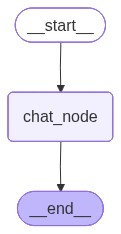

In [12]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

checkpointer = MemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [25]:
config = {"configurable": {"thread_id":"1234"}}

initial_input = {
    "messages":[
        ("user", "Explain gradient decsent in simple terms. ")
    ]
}
result = workflow.invoke(initial_input, config=config)

In [26]:
message = result["__interrupt__"][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question',
 'question': 'Explain gradient decsent in simple terms. ',
 'Instruction': 'Approve this question? yes/no'}

In [27]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n):")

In [28]:
final_result = workflow.invoke(
    Command(resume={"approved": user_input}),
    config=config
)

In [ ]:
print(final_result)

{'messages': [HumanMessage(content='Explain gradient decsent in simple terms. ', id='2300c8bf-ebaf-407c-9e6f-1cfe802f903b'), HumanMessage(content='Explain gradient decsent in simple terms. ', id='8a3c67c4-b725-4f24-91e8-42a6487c52d6'), AIMessage(content='Not Approved', id='f4bf8566-c4f5-40f6-96a1-b78d74532490'), HumanMessage(content='Explain gradient decsent in simple terms. ', id='2a762b2f-fc96-44ee-ad2b-7397d342f6e5'), AIMessage(content="Sure! Imagine you're standing on a hill and you want to get to the lowest point. The gradient descent is like walking downhill in the steepest direction. You look at the slope around you and take a step in the direction where the ground is most steeply downhill. You keep doing this, taking small steps, and each time you move to a spot that is a little bit lower. Over time, you'll keep going downhill until you reach the bottom of the hill.\n\nIn machine learning, we use gradient descent to find the values of parameters (like weights in a neural networ